# Statistical Summary

## Raw Datasets

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Function to generate a summary table for all datasets
def summarize_datasets(datasets):
    # Initialize a list to store summary data
    summary_data = []
    
    for name, df in datasets.items():
        # Number of observations and columns
        n_obs = df.shape[0]
        n_cols = df.shape[1]
        
        # Numerical columns for statistics
        numerical_cols = df.select_dtypes(include=[np.number]).columns
        n_numerical = len(numerical_cols)
        
        # Basic statistics for numerical columns
        mean_values = df[numerical_cols].mean().mean() if n_numerical > 0 else np.nan
        std_values = df[numerical_cols].std().mean() if n_numerical > 0 else np.nan
        min_values = df[numerical_cols].min().mean() if n_numerical > 0 else np.nan
        max_values = df[numerical_cols].max().mean() if n_numerical > 0 else np.nan
        
        # Missing values
        missing_values = df.isnull().sum().sum()
        
        # Append summary to list
        summary_data.append({
            'Dataset Name': name,
            'Observations': n_obs,
            'Columns': n_cols,
            'Numerical Columns': n_numerical,
            'Mean': f"{mean_values:.2f}" if not np.isnan(mean_values) else 'N/A',
            'Std Dev': f"{std_values:.2f}" if not np.isnan(std_values) else 'N/A',
            'Min': f"{min_values:.2f}" if not np.isnan(min_values) else 'N/A',
            'Max': f"{max_values:.2f}" if not np.isnan(max_values) else 'N/A',
            'Missing Values': missing_values
        })
    
    # Create DataFrame from summary data
    summary_df = pd.DataFrame(summary_data)
    return summary_df

# Load datasets using full file paths
datasets = {
    'Finance Economics': pd.read_csv('/Users/admin/LG/TextToSQL/dataset/finance_economics_dataset.csv'),
    'Country Income': pd.read_csv('/Users/admin/LG/TextToSQL/dataset/country_income.csv'),
    'Global Indicators': pd.read_csv('/Users/admin/LG/TextToSQL/dataset/global_development_indicators.csv'),
    'World Happiness': pd.read_csv('/Users/admin/LG/TextToSQL/dataset/world_happiness_report.csv')
}

# Generate and display summary table
summary_table = summarize_datasets(datasets)
print("\nSummary Table for All Datasets:")
print(summary_table)

# Save the table to a CSV for your research paper
summary_table.to_csv('/Users/admin/LG/TextToSQL/dataset_summary.csv', index=False)


Summary Table for All Datasets:
        Dataset Name  Observations  Columns  Numerical Columns  \
0  Finance Economics          3000       24                 22   
1     Country Income         85220       12                  5   
2  Global Indicators          5556       47                 42   
3    World Happiness          2199       13                 11   

             Mean          Std Dev             Min               Max  \
0     22883237.52      12996492.49        74625.80       45457307.52   
1      6192424.72      23067735.11         2597.00      279430647.54   
2  47824427568.42  173700163637.54  -1227171980.83  2085139481866.80   
3          190.55             1.35          183.55            192.95   

   Missing Values  
0               0  
1               0  
2           34439  
3             822  


## Question Datasets

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import json
from collections import Counter
import re

# Function to compute statistics for queries in a JSON file
def analyze_queries(file_path, dataset_name):
    # Load the JSON file
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    queries = data.get('user_queries', [])
    n_queries = len(queries)
    
    if n_queries == 0:
        return None
    
    # Compute token lengths (assuming tokens are words split by whitespace)
    token_lengths = [len(re.findall(r'\b\w+\b', query)) for query in queries]  # Word count using regex for better accuracy
    
    # Basic statistics
    mean_tokens = np.mean(token_lengths) if token_lengths else np.nan
    min_tokens = np.min(token_lengths) if token_lengths else np.nan
    max_tokens = np.max(token_lengths) if token_lengths else np.nan
    std_tokens = np.std(token_lengths) if token_lengths else np.nan
    median_tokens = np.median(token_lengths) if token_lengths else np.nan
    
    # Character lengths for additional info
    char_lengths = [len(query) for query in queries]
    mean_chars = np.mean(char_lengths)
    min_chars = np.min(char_lengths)
    max_chars = np.max(char_lengths)
    
    # Most common words (top 5)
    all_words = ' '.join(queries).lower().split()
    common_words = Counter(all_words).most_common(5)
    
    # Query types or patterns (e.g., count of queries with years, countries)
    year_count = sum(1 for query in queries if re.search(r'\d{4}', query))
    country_count = sum(1 for query in queries if any(word in query.lower() for word in ['vietnam', 'us', 'thailand', 'singapore', 'china']))  # Example based on sample
    
    # Return summary as dict
    return {
        'Dataset Name': dataset_name,
        'Number of Queries': n_queries,
        'Mean Token Length': f"{mean_tokens:.2f}",
        'Min Token Length': min_tokens,
        'Max Token Length': max_tokens,
        # 'Std Dev Tokens': f"{std_tokens:.2f}",
        'Median Token Length': f"{median_tokens:.2f}",
        # 'Mean Char Length': f"{mean_chars:.2f}",
        # 'Min Char Length': min_chars,
        # 'Max Char Length': max_chars,
        'Queries with Years': year_count,
        'Queries with Countries': country_count,
        'Top 5 Common Words': ', '.join([f"{word} ({count})" for word, count in common_words])
    }

# List of datasets with full paths
dataset_paths = {
    'Country Income': '/Users/admin/LG/TextToSQL/query/input/country_income.json',
    'Finance Economics': '/Users/admin/LG/TextToSQL/query/input/finance_economics.json',
    'Global Development': '/Users/admin/LG/TextToSQL/query/input/global_development.json',
    'Happiness Record': '/Users/admin/LG/TextToSQL/query/input/happiness_record.json'
}

# Generate summaries for each dataset
summary_data = []
for name, path in dataset_paths.items():
    summary = analyze_queries(path, name)
    if summary:
        summary_data.append(summary)

# Create DataFrame from summaries
summary_df = pd.DataFrame(summary_data)

# Display the summary table
print("\nStatistical Summary of User Queries Across Datasets:")
print(summary_df)

# Optionally, save to CSV
summary_df.to_csv('/Users/admin/LG/TextToSQL/query_summary.csv', index=False)


Statistical Summary of User Queries Across Datasets:
         Dataset Name  Number of Queries Mean Token Length  Min Token Length  \
0      Country Income                 31             14.19                 5   
1   Finance Economics                 31             13.87                 5   
2  Global Development                 31             12.61                 8   
3    Happiness Record                 31             13.00                 9   

   Max Token Length Median Token Length  Queries with Years  \
0                35               13.00                  22   
1                30               12.00                   7   
2                20               13.00                  16   
3                22               12.00                  16   

   Queries with Countries                                 Top 5 Common Words  
0                      18  of (35), the (31), in (22), income (20), what ...  
1                       3      the (34), of (16), is (13), to (11), and

# Evaluation Metrics

## Score Summary

In [29]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the base path
base_path = '/Users/admin/LG/TextToSQL/query/output'

# Define model order
model_order = [
    'llama3.2:3b',
    'cogito:3b',
    'deepseek-r1:7b',
    'mistral:7b',
    'phi4-mini:3.8b',
    'phi3.5:3.8b',
    'qwen2.5:3b',
    'qwen3:4b',
    'gemma3:4b',
    'gemma3n:e4b'
]

# Mapping for naming conventions
model_mapping = {
    'llama3.2:3b': 'llama3.2:3b',
    'qwen2.5:3b': 'qwen2.5:3b'
}

# Dataset display order
dataset_display_order = [
    'Finance and Economics',
    'Global Income Statistics',
    'Global Development Indicators',
    'World Happiness Report'
]

# Folder and display mappings
dataset_mapping = {
    'finance_economics': 'Finance and Economics',
    'country_income': 'Global Income Statistics',
    'global_development': 'Global Development Indicators',
    'happiness_record': 'World Happiness Report'
}
dataset_folders = [
    'country_income',
    'finance_economics',
    'global_development',
    'happiness_record'
]

# Custom color palette
custom_palette = {
    'Finance and Economics': '#1f77b4',
    'Global Income Statistics': '#d62728',
    'Global Development Indicators': '#2ca02c',
    'World Happiness Report': '#ff7f0e'
}

# Collect data
data = []

for model_display in model_order:
    model_folder = model_mapping.get(model_display, model_display)
    for ds_folder, ds_display in zip(dataset_folders, dataset_display_order):
        file_path = os.path.join(base_path, model_folder, ds_folder, 'comparison', 'metrics.json')
        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                metrics = json.load(f)
            if metrics:
                num_questions = len(metrics)
                avg_metrics = {}
                metric_names = [
                    'fuzzy_string_similarity',
                    'ast_similarity',
                    'jaccard_component_similarity',
                    'fuzzy_logical_form_similarity',
                    'cosine_similarity'
                ]
                for metric_name in metric_names:
                    total = sum(q_metrics.get(metric_name, 0) for q_metrics in metrics.values())
                    avg_metrics[metric_name] = total / num_questions

                for metric_name, avg_value in avg_metrics.items():
                    data.append({
                        'model': model_display,
                        'dataset': ds_display,
                        'metric': metric_name,
                        'average': avg_value
                    })

# Create DataFrame
df = pd.DataFrame(data)
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)
df['dataset'] = pd.Categorical(df['dataset'], categories=dataset_display_order, ordered=True)

print("FULL DATASET USED FOR PLOTS (All Rows):")
print(df.to_string(index=False))
print("\n" + "="*100)

# Visualization
sns.set_theme(style="whitegrid")

# Font size configuration
TITLE_SIZE = 22
LABEL_SIZE = 18
TICK_SIZE = 14
LEGEND_SIZE = 14

unique_metrics = df['metric'].unique()
for metric in unique_metrics:
    plt.figure(figsize=(18, 9), dpi=600)
    ax = sns.barplot(
        data=df[df['metric'] == metric],
        x='model',
        y='average',
        hue='dataset',
        hue_order=dataset_display_order,
        palette=custom_palette
    )

    plt.title(f'Average {metric.replace("_", " ").title()}', fontsize=TITLE_SIZE, pad=30)
    plt.xlabel('Model', fontsize=LABEL_SIZE, labelpad=10)
    plt.ylabel('Average Value', fontsize=LABEL_SIZE, labelpad=10)

    # ✅ Make only model names larger and bolder
    plt.xticks(rotation=45, ha='right', fontsize=20)
    plt.yticks(fontsize=TICK_SIZE)

    # Fix y-axis range
    plt.ylim(0, 1.3)

    # Keep legend inside
    plt.legend(
        title='Dataset',
        loc='upper right',
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE + 2,
        frameon=True
    )

    # Adjust top margin
    plt.subplots_adjust(top=0.88)
    plt.tight_layout()

    # ✅ Use abbreviations for exported plot filenames
    metric_abbr = {
        'fuzzy_string_similarity': 'fss',
        'ast_similarity': 'asts',
        'jaccard_component_similarity': 'jcs',
        'fuzzy_logical_form_similarity': 'flfs',
        'cosine_similarity': 'cs'
    }
    abbr = metric_abbr.get(metric, metric.replace("_", "-").lower())

    output_filename = f'{abbr}.png'
    plt.savefig(output_filename, dpi=600, bbox_inches='tight')
    plt.close()
    print(f"Saved plot: {output_filename}")

# Compute overall averages
overall_df = df.groupby(['model', 'metric'])['average'].mean().reset_index()
overall_df['model'] = pd.Categorical(overall_df['model'], categories=model_order, ordered=True)

# Pivot table for summary
metric_display_order = [
    'fuzzy_string_similarity',
    'ast_similarity',
    'jaccard_component_similarity',
    'fuzzy_logical_form_similarity',
    'cosine_similarity'
]
pivot_df = overall_df.pivot(index='model', columns='metric', values='average').round(4)
pivot_df = pivot_df.reindex(columns=metric_display_order)

print("\n" + "="*120)
print("OVERALL AVERAGE METRICS BY MODEL (Averaged Across All Datasets)")
print("="*120)
print(pivot_df.to_string())

# Summary statistics
summary_stats = overall_df.groupby('metric')['average'].agg(['mean', 'std', 'min', 'max']).round(4)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(summary_stats)

# Model ranking
print("\n" + "="*80)
print("MODEL RANKINGS BY METRIC (Top 3)")
print("="*80)
for metric in metric_display_order:
    if metric in overall_df['metric'].values:
        metric_data = overall_df[overall_df['metric'] == metric].sort_values('average', ascending=False)
        print(f"\n{metric.replace('_', ' ').title()}:")
        for i, (_, row) in enumerate(metric_data.head(3).iterrows(), 1):
            print(f"  {i}. {row['model']:<18}: {row['average']:.4f}")

FULL DATASET USED FOR PLOTS (All Rows):
         model                       dataset                        metric  average
   llama3.2:3b         Finance and Economics       fuzzy_string_similarity 0.632838
   llama3.2:3b         Finance and Economics                ast_similarity 0.604174
   llama3.2:3b         Finance and Economics  jaccard_component_similarity 0.370968
   llama3.2:3b         Finance and Economics fuzzy_logical_form_similarity 0.677320
   llama3.2:3b         Finance and Economics             cosine_similarity 0.816451
   llama3.2:3b      Global Income Statistics       fuzzy_string_similarity 0.620881
   llama3.2:3b      Global Income Statistics                ast_similarity 0.596308
   llama3.2:3b      Global Income Statistics  jaccard_component_similarity 0.416667
   llama3.2:3b      Global Income Statistics fuzzy_logical_form_similarity 0.586011
   llama3.2:3b      Global Income Statistics             cosine_similarity 0.743933
   llama3.2:3b Global Development In

/var/folders/fk/9bz423fn31b0k0lrps5xjjww0000gp/T/ipykernel_71592/809711763.py:162: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_df = df.groupby(['model', 'metric'])['average'].mean().reset_index()


## Generation Time and Actionable Query

In [10]:
import os
import json
from datetime import datetime

ROOT_DIR = "/Users/admin/LG/TextToSQL/query/output"
DATASETS = ["country_income", "finance_economics", "global_development", "happiness_record"]
MODELS = [
    "qwen3:4b", "qwen2.5:3b", "phi4-mini:3.8b", "phi3.5:3.8b", "mistral:7b",
    "llama3.2:latest", "gemma3:4b", "gemma3n:e4b",
    "deepseek-r1:7b", "cogito:3b"
]

NO_RECORD = "query ran successfully, no record found"
ERROR = "error"

TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
CSV_FILE = f"FINAL_RUNNABLE_RATES_CORRECT_{TIMESTAMP}.csv"

stats = {m: {"checked": 0, "empty": 0, "error": 0} for m in MODELS}

print("Counting runnable queries across all datasets...\n")

for model in MODELS:
    model_path = os.path.join(ROOT_DIR, model)
    if not os.path.isdir(model_path):
        continue

    for dataset in DATASETS:
        folder = os.path.join(model_path, dataset, "natural_res")
        if not os.path.exists(folder):
            continue

        for file in os.listdir(folder):
            if not file.endswith(".json"):
                continue
            path = os.path.join(folder, file)
            try:
                with open(path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                stats[model]["checked"] += 1
                raw = str(data.get("raw_results", "")).lower()
                if NO_RECORD.lower() in raw:
                    stats[model]["empty"] += 1
                elif ERROR in raw:
                    stats[model]["error"] += 1
            except:
                stats[model]["error"] += 1

# FINAL LEADERBOARD — NOW 100% CORRECT
print("\n" + "="*82)
print("FINAL: RUNNABLE SUCCESS RATE (Across All Processed Queries)")
print("="*82)
print(f"{'Rank':<4} {'Model':<20} {'Checked':<7} {'Empty':<6} {'Error':<6} {'Runnable':<8} {'Success Rate'}")
print("-" * 82)

results = []
for rank, model in enumerate(MODELS, 1):
    s = stats[model]
    checked = s["checked"]
    runnable = checked - s["empty"] - s["error"]
    rate = (runnable / checked * 100) if checked > 0 else 0

    print(f"{rank:<4} {model:<20} {checked:<7} {s['empty']:<6} {s['error']:<6} {runnable:<8} {rate:6.1f}%")
    results.append({
        "Rank": rank,
        "Model": model,
        "Checked": checked,
        "Empty": s["empty"],
        "Error": s["error"],
        "Runnable": runnable,
        "Success Rate (%)": round(rate, 1)
    })

# Save CSV
import csv
with open(CSV_FILE, 'w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=results[0].keys())
    w.writeheader()
    w.writerows(results)

Counting runnable queries across all datasets...


FINAL: RUNNABLE SUCCESS RATE (Across All Processed Queries)
Rank Model                Checked Empty  Error  Runnable Success Rate
----------------------------------------------------------------------------------
1    qwen3:4b             124     24     3      97         78.2%
2    qwen2.5:3b           124     19     34     71         57.3%
3    phi4-mini:3.8b       124     13     74     37         29.8%
4    phi3.5:3.8b          124     12     99     13         10.5%
5    mistral:7b           124     2      106    16         12.9%
6    llama3.2:latest      0       0      0      0           0.0%
7    gemma3:4b            124     20     13     91         73.4%
8    gemma3n:e4b          123     20     50     53         43.1%
9    deepseek-r1:7b       124     0      120    4           3.2%
10   cogito:3b            124     22     38     64         51.6%


## Metrics by Groups

📊 Data loaded:
                Basic Retrieval  Aggregation and Calculation  \
model                                                          
llama3.2:3b               0.797                        0.600   
cogito:3b                 0.728                        0.546   
deepseek-r1:7b            0.540                        0.400   
mistral:7b                0.592                        0.417   
phi4-mini:3.8b            0.715                        0.601   
phi3.5:3.8b               0.485                        0.301   
qwen2.5:3b                0.807                        0.637   
qwen3:4b                  0.885                        0.733   
gemma3:4b                 0.849                        0.646   
gemma3n:e4b               0.796                        0.641   

                Reasoning and Strategize  
model                                     
llama3.2:3b                        0.482  
cogito:3b                          0.460  
deepseek-r1:7b                     0.334  
m

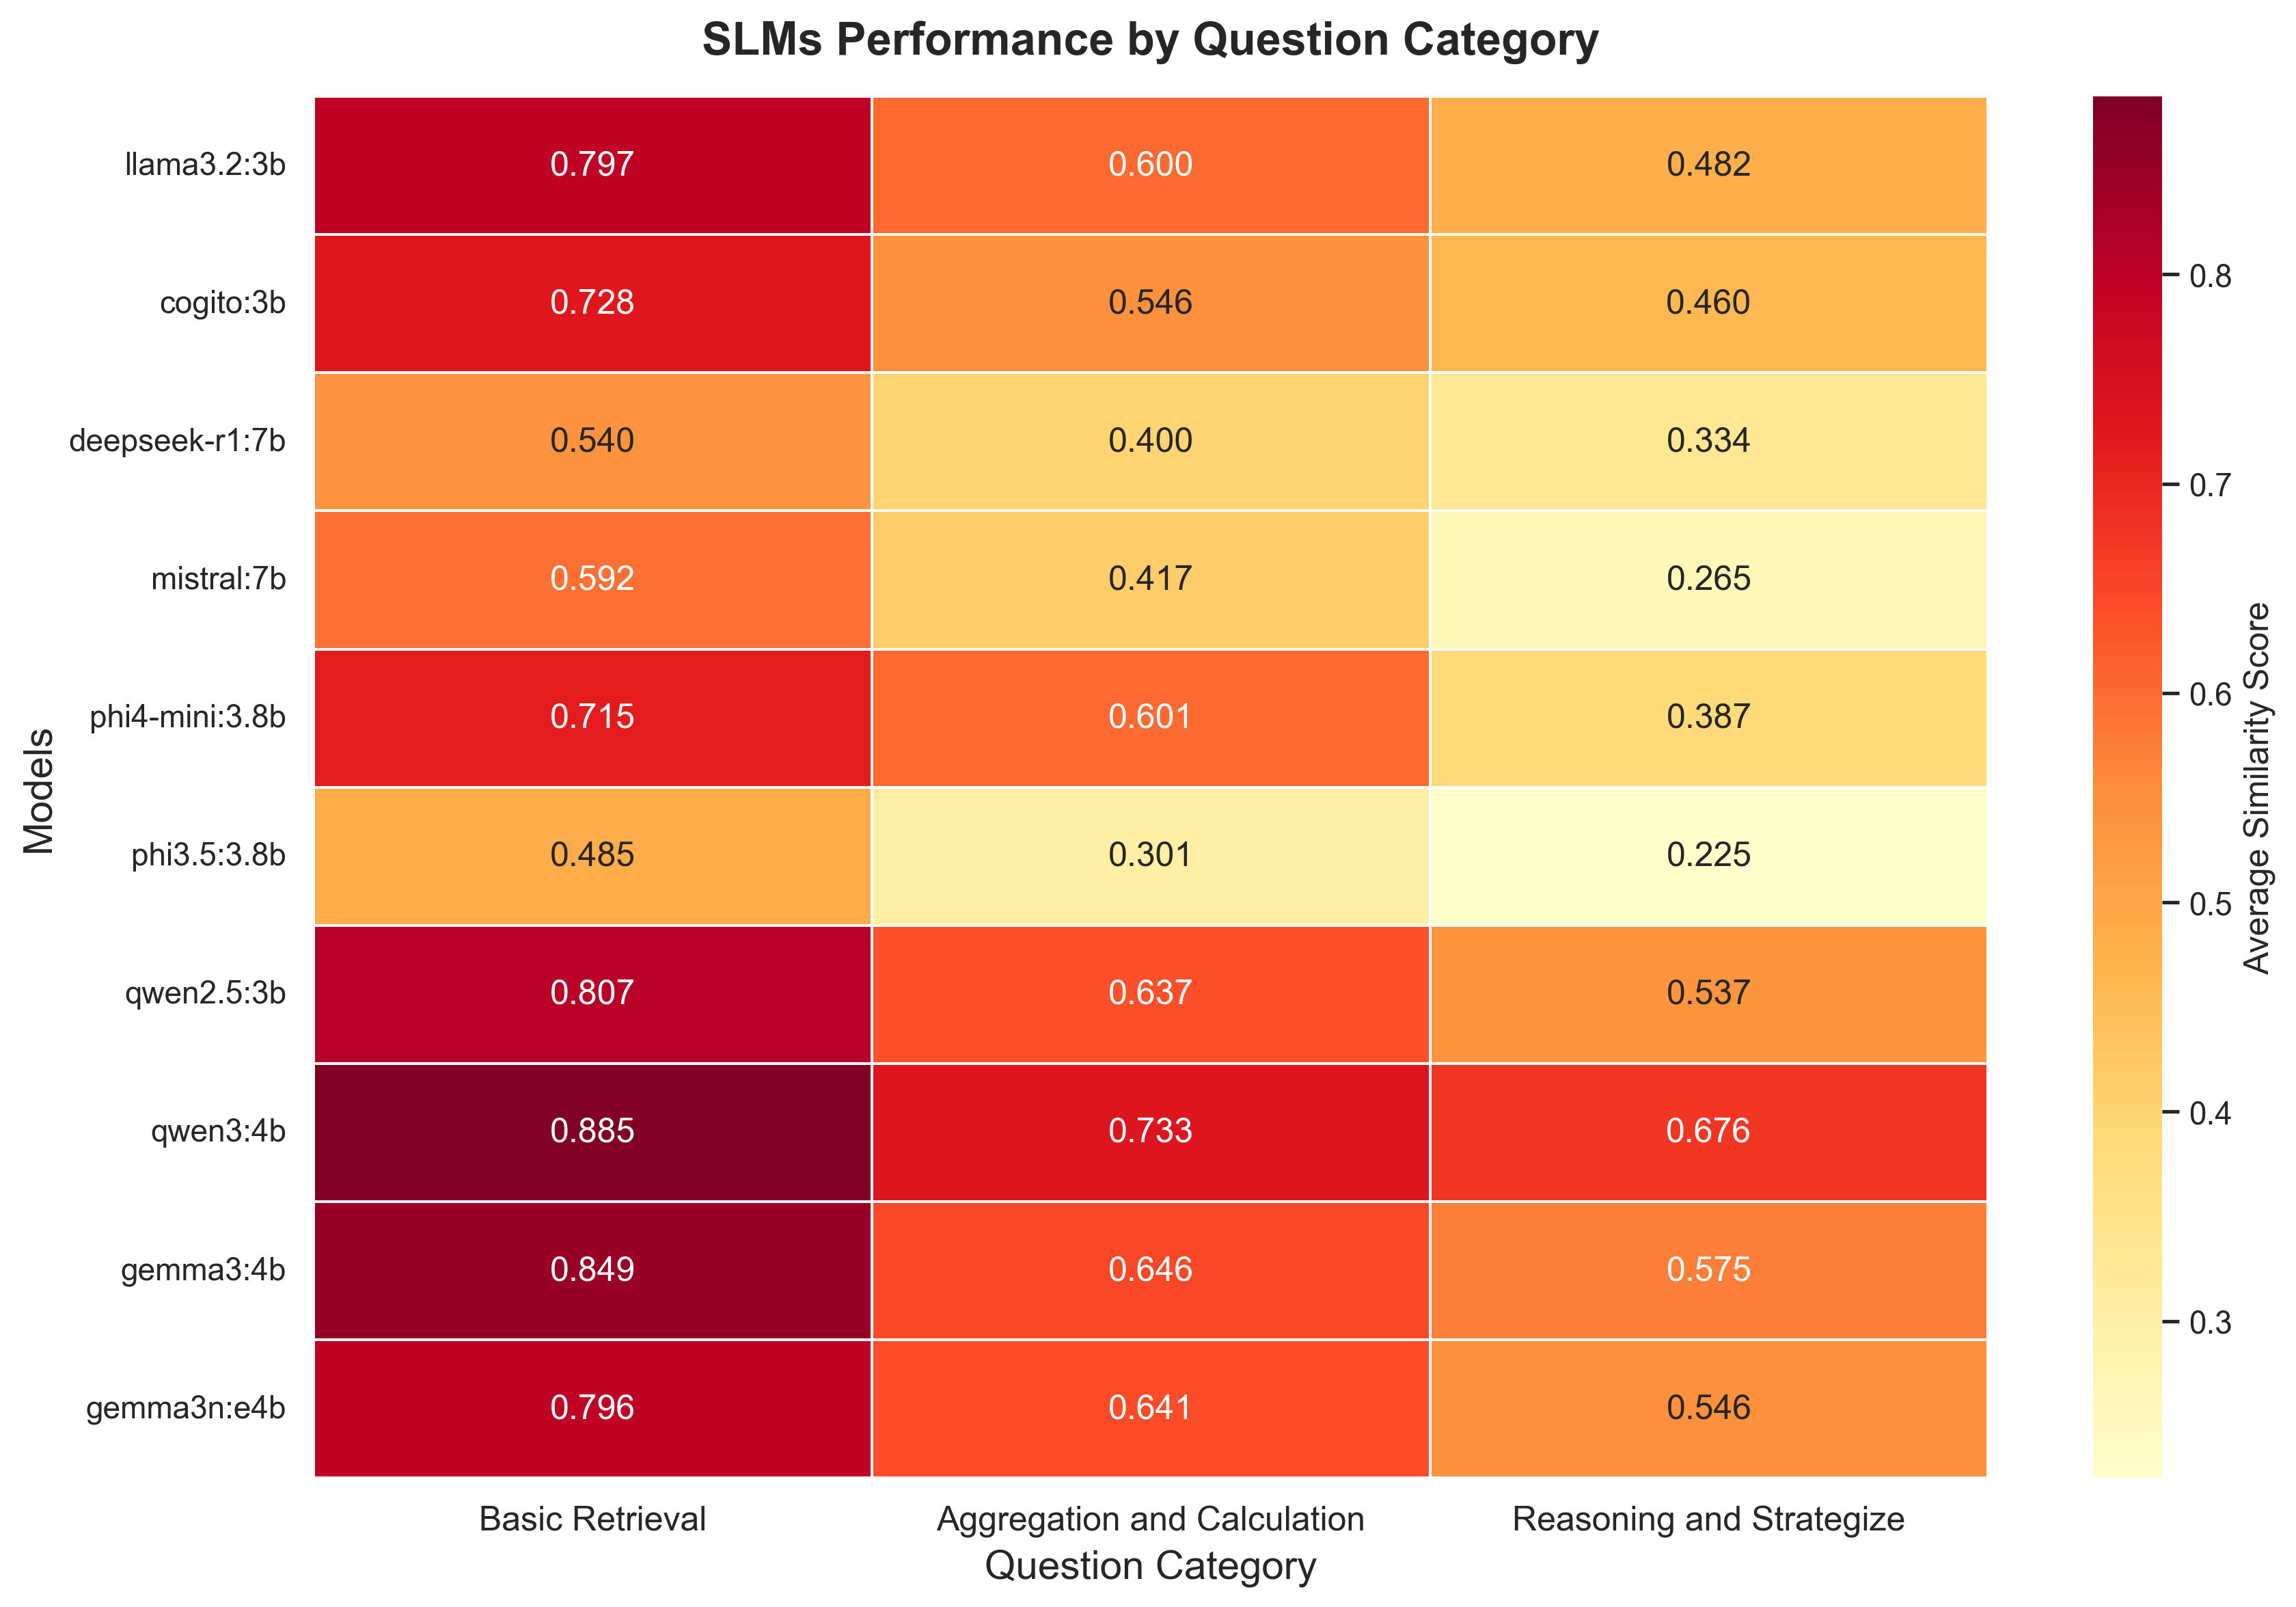

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your new results
data_path = '/Users/admin/LG/TextToSQL/dataset/model_vs_difficulty_summary.csv'
heatmap_data = pd.read_csv(data_path, index_col=0)

# Set categorical order for proper model sorting
model_order = [
    'llama3.2:3b', 'cogito:3b', 'deepseek-r1:7b', 'mistral:7b',
    'phi4-mini:3.8b', 'phi3.5:3.8b', 'qwen2.5:3b', 'qwen3:4b',
    'gemma3:4b', 'gemma3n:e4b'
]

heatmap_data = heatmap_data.reindex(model_order)

print("📊 Data loaded:")
print(heatmap_data.round(3))

# 🔥 ORIGINAL HEATMAP STYLE (Your favorite!)
plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(heatmap_data, 
            annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Similarity Score'},
            linewidths=0.5, linecolor='white')

plt.title('SLMs Performance by Question Category', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Question Category', fontsize=14)
plt.ylabel('Models', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Save publication-ready
plt.savefig('SLMs_performance_by_question_category.png', 
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('SLMs_performance_by_question_category.pdf', 
            bbox_inches='tight', facecolor='white')
plt.show()

Processing SQL comparisons...

🎨 Creating HEATMAP: Model Performance by Difficulty Group...


/var/folders/fk/9bz423fn31b0k0lrps5xjjww0000gp/T/ipykernel_71592/272421268.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(['model', 'group'])['average'].mean().reset_index()


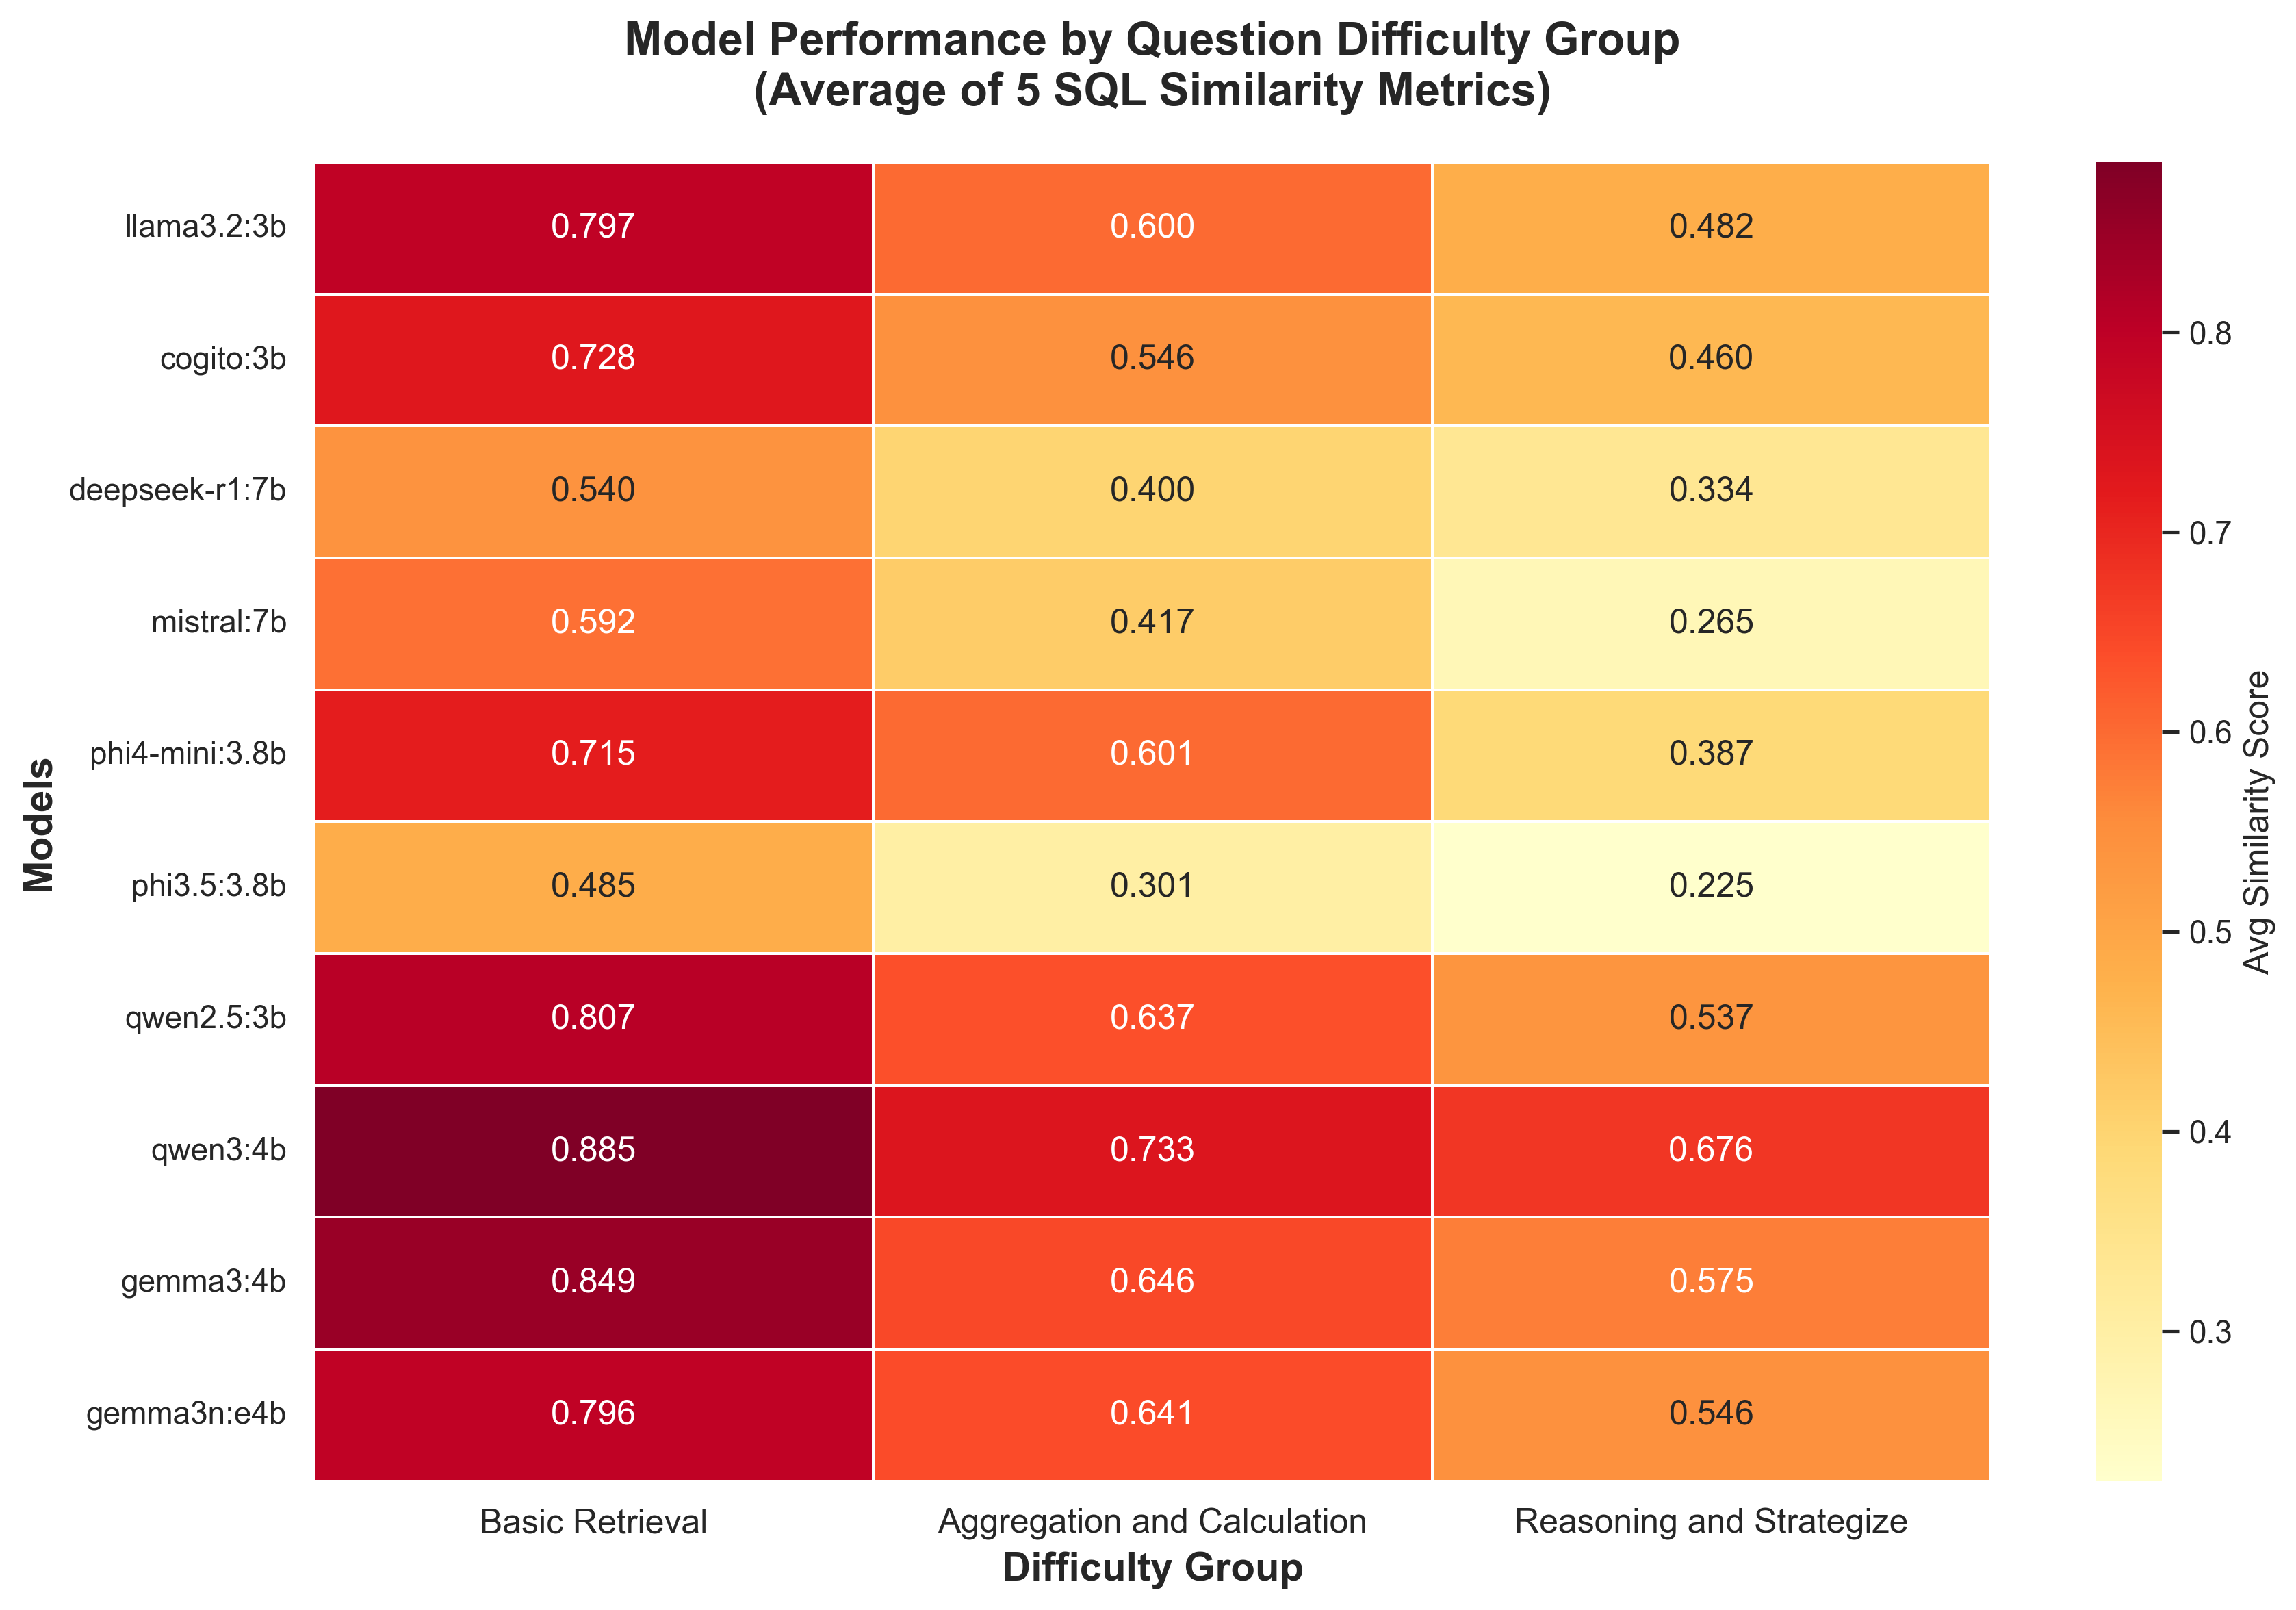

✅ Saved: model_performance_by_difficulty_heatmap.png

🏆 BEST & WORST MODELS BY DIFFICULTY GROUP

Basic Retrieval:
  🥇 1st: qwen3:4b           | 0.885
  🥈 2nd: gemma3:4b          | 0.849
  🥉 3rd: qwen2.5:3b         | 0.807
  😞 Last: phi3.5:3.8b        | 0.485

Aggregation and Calculation:
  🥇 1st: qwen3:4b           | 0.733
  🥈 2nd: gemma3:4b          | 0.646
  🥉 3rd: gemma3n:e4b        | 0.641
  😞 Last: phi3.5:3.8b        | 0.301

Reasoning and Strategize:
  🥇 1st: qwen3:4b           | 0.676
  🥈 2nd: gemma3:4b          | 0.575
  🥉 3rd: gemma3n:e4b        | 0.546
  😞 Last: phi3.5:3.8b        | 0.225

📊 MODEL PERFORMANCE SUMMARY (Avg of 5 Metrics)
group           Basic Retrieval  Aggregation and Calculation  Reasoning and Strategize
model                                                                                 
llama3.2:3b               0.797                        0.600                     0.482
cogito:3b                 0.728                        0.546                     0.46

/var/folders/fk/9bz423fn31b0k0lrps5xjjww0000gp/T/ipykernel_71592/272421268.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_scores = df[df['group'] == group_name].groupby('model')['average'].mean().sort_values(ascending=False)


In [27]:
import os
# COMPLETELY DISABLE MPS - FORCE CPU ONLY (AGGRESSIVE)
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
os.environ['MPS_NO_PYTHON'] = '1'
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_DISABLE_MPS'] = '1'
import torch
torch.backends.mps.is_available = lambda : False
torch.backends.mps.is_built = lambda : False

import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sys.path.append('/Users/admin/LG/TextToSQL/utils')
from metric_utils import (
    load_sql_from_json, 
    fuzzy_string_similarity, 
    ast_similarity, 
    jaccard_component_similarity, 
    fuzzy_logical_form_similarity
)

# CUSTOM CPU-ONLY COSINE SIMILARITY
def cosine_similarity_score_cpu(gold_sql, pred_sql):
    try:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.metrics.pairwise import cosine_similarity
        vectorizer = TfidfVectorizer(max_features=1000, lowercase=True, stop_words='english')
        tfidf_matrix = vectorizer.fit_transform([gold_sql, pred_sql])
        sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        return float(sim)
    except:
        return 0.0

# [KEEP ALL YOUR ORIGINAL SETUP CODE - base_path, model_order, etc.]
base_path = '/Users/admin/LG/TextToSQL/query/output'
model_order = [
    'llama3.2:3b', 'cogito:3b', 'deepseek-r1:7b', 'mistral:7b',
    'phi4-mini:3.8b', 'phi3.5:3.8b', 'qwen2.5:3b', 'qwen3:4b',
    'gemma3:4b', 'gemma3n:e4b'
]
model_mapping = {'llama3.2:3b': 'llama3.2:3b', 'qwen2.5:3b': 'qwen2.5:3b'}
dataset_display_order = ['Finance and Economics', 'Global Income Statistics', 'Global Development Indicators', 'World Happiness Report']
dataset_folders = ['country_income', 'finance_economics', 'global_development', 'happiness_record']
question_groups = {'Basic Retrieval': (1, 10), 'Aggregation and Calculation': (11, 20), 'Reasoning and Strategize': (21, 30)}
metric_names = ['fuzzy_string_similarity', 'ast_similarity', 'jaccard_component_similarity', 'fuzzy_logical_form_similarity', 'cosine_similarity']

# [YOUR PROCESSING CODE HERE - same as before]
all_data = []
print("Processing SQL comparisons...")

for model_display in model_order:
    model_folder = model_mapping.get(model_display, model_display)
    for ds_folder, ds_display in zip(dataset_folders, dataset_display_order):
        pred_sql_path = os.path.join(base_path, model_folder, ds_folder, 'pred_sql')
        gold_sql_path = os.path.join(base_path, model_folder, ds_folder, 'gold_sql')
        
        if not (os.path.exists(pred_sql_path) and os.path.exists(gold_sql_path)):
            continue
            
        for group_name, (start_q, end_q) in question_groups.items():
            group_metrics = []
            for q_num in range(start_q, end_q + 1):
                pred_file = os.path.join(pred_sql_path, f'question_{q_num}.json')
                gold_file = os.path.join(gold_sql_path, f'question_{q_num}.json')
                
                if os.path.exists(pred_file) and os.path.exists(gold_file):
                    gold_sql = load_sql_from_json(gold_file)
                    pred_sql = load_sql_from_json(pred_file)
                    
                    if gold_sql and pred_sql:
                        metrics = {
                            'fuzzy_string_similarity': fuzzy_string_similarity(gold_sql, pred_sql),
                            'ast_similarity': ast_similarity(gold_sql, pred_sql),
                            'jaccard_component_similarity': jaccard_component_similarity(gold_sql, pred_sql),
                            'fuzzy_logical_form_similarity': fuzzy_logical_form_similarity(gold_sql, pred_sql),
                            'cosine_similarity': cosine_similarity_score_cpu(gold_sql, pred_sql)
                        }
                        group_metrics.append(metrics)
            
            if group_metrics:
                num_questions = len(group_metrics)
                avg_metrics = {m: sum(mg.get(m, 0) for mg in group_metrics) / num_questions 
                              for m in metric_names}
                
                for metric_name, avg_value in avg_metrics.items():
                    all_data.append({
                        'model': model_display, 'dataset': ds_display, 'group': group_name,
                        'metric': metric_name, 'average': round(avg_value, 4), 'n_questions': num_questions
                    })

df = pd.DataFrame(all_data)
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)
df['group'] = pd.Categorical(df['group'], categories=list(question_groups.keys()), ordered=True)

# 🔥 HEATMAP VISUALIZATION - MODEL vs DIFFICULTY GROUPS
print("\n🎨 Creating HEATMAP: Model Performance by Difficulty Group...")

# Average across ALL 5 metrics for each model-group combo
heatmap_data = df.groupby(['model', 'group'])['average'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='model', columns='group', values='average').round(3)

# Create heatmap
plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(heatmap_pivot, 
            annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Avg Similarity Score'},
            linewidths=0.5, linecolor='white')

plt.title('Model Performance by Question Difficulty Group\n(Average of 5 SQL Similarity Metrics)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Difficulty Group', fontsize=14, fontweight='bold')
plt.ylabel('Models', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('model_performance_by_difficulty_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: model_performance_by_difficulty_heatmap.png")

# 🔥 TOP/BOTTOM PERFORMERS BY GROUP
print("\n" + "="*80)
print("🏆 BEST & WORST MODELS BY DIFFICULTY GROUP")
print("="*80)

for group_name in question_groups.keys():
    group_scores = df[df['group'] == group_name].groupby('model')['average'].mean().sort_values(ascending=False)
    print(f"\n{group_name}:")
    print(f"  🥇 1st: {group_scores.index[0]:<18} | {group_scores.iloc[0]:.3f}")
    print(f"  🥈 2nd: {group_scores.index[1]:<18} | {group_scores.iloc[1]:.3f}")
    print(f"  🥉 3rd: {group_scores.index[2]:<18} | {group_scores.iloc[2]:.3f}")
    print(f"  😞 Last: {group_scores.index[-1]:<18} | {group_scores.iloc[-1]:.3f}")

# 🔥 CONSOLIDATED TABLE
print("\n" + "="*80)
print("📊 MODEL PERFORMANCE SUMMARY (Avg of 5 Metrics)")
print("="*80)
print(heatmap_pivot.round(3).to_string())

# Save clean table
heatmap_pivot.to_csv('model_vs_difficulty_summary.csv')
print("\n💾 Saved: model_vs_difficulty_summary.csv")

print("\n🎉 ANALYSIS COMPLETE!")
print("📈 Key files:")
print("   • model_performance_by_difficulty_heatmap.png")
print("   • model_vs_difficulty_summary.csv")

## Power Consumption

In [1]:
import pandas as pd

# Path to your summary file
file_path = "/Users/admin/LG/TextToSQL/dataset/summary/power_summary.csv"

# Read the CSV file
df = pd.read_csv(file_path)

# Define the key metrics to calculate averages for
key_metrics = ['total_time_s', 'gpu_energy_j', 'total_energy_j', 'avg_power_w', 'carbon_gco2eq']

# Group by model and calculate the average for each metric
model_averages = df.groupby('model')[key_metrics].mean()

# Round the results for cleaner presentation
model_averages = model_averages.round(4)

# Print the results in a formatted table
print("Average Performance Metrics by Model:")
print("=" * 80)
print(f"{'Model':<20} {'Time(s)':<10} {'GPU Energy(J)':<12} {'Total Energy(J)':<14} {'Avg Power(W)':<12} {'Carbon(gCO2)':<12}")
print("-" * 80)

for model in model_averages.index:
    row = model_averages.loc[model]
    print(f"{model:<20} {row['total_time_s']:<10.4f} {row['gpu_energy_j']:<12.4f} {row['total_energy_j']:<14.4f} {row['avg_power_w']:<12.2f} {row['carbon_gco2eq']:<12.4f}")

# Optional: Also print summary statistics across all models
print("\n" + "=" * 80)
print("Overall Summary Across All Models:")
print(f"Total number of questions processed: {len(df)}")
print(f"Number of models evaluated: {len(model_averages)}")

# Calculate and display total energy across all models
total_energy_all = df['total_energy_j'].sum()
print(f"Total energy consumption across all evaluations: {total_energy_all:.2f} J ({total_energy_all/3600:.2f} Wh)")

# Display the results as a DataFrame for easy copying/exporting
print("\nDetailed average results:")
print(model_averages)

# Optional: Save the averaged results to a new file
output_file = "model_averages.csv"
model_averages.to_csv(output_file)
print(f"\nAveraged results have also been saved to: {output_file}")

Average Performance Metrics by Model:
Model                Time(s)    GPU Energy(J) Total Energy(J) Avg Power(W) Carbon(gCO2)
--------------------------------------------------------------------------------
cogito:3b            21.5202    0.0000       223.6104       10.15        24.8456     
deepseek-r1:7b       110.1881   0.0000       878.8941       7.81         97.6549     
gemma3:4b            13.0253    0.0000       71.4182        5.59         7.9354      
gemma3n:e4b          34.2494    0.0000       627.3158       7.46         69.7018     
llama3.2             9.7012     0.0000       82.1374        8.55         9.1264      
mistral:7b           11.4302    0.0000       94.0368        8.26         10.4485     
phi3.5:3.8b          27.6926    0.0000       273.4838       9.43         30.3871     
phi4-mini:3.8b       38.0120    0.0000       264.6122       7.16         29.4014     
qwen2.5:3b           11.6853    0.0000       56.5476        4.92         6.2831      
qwen3:4b           

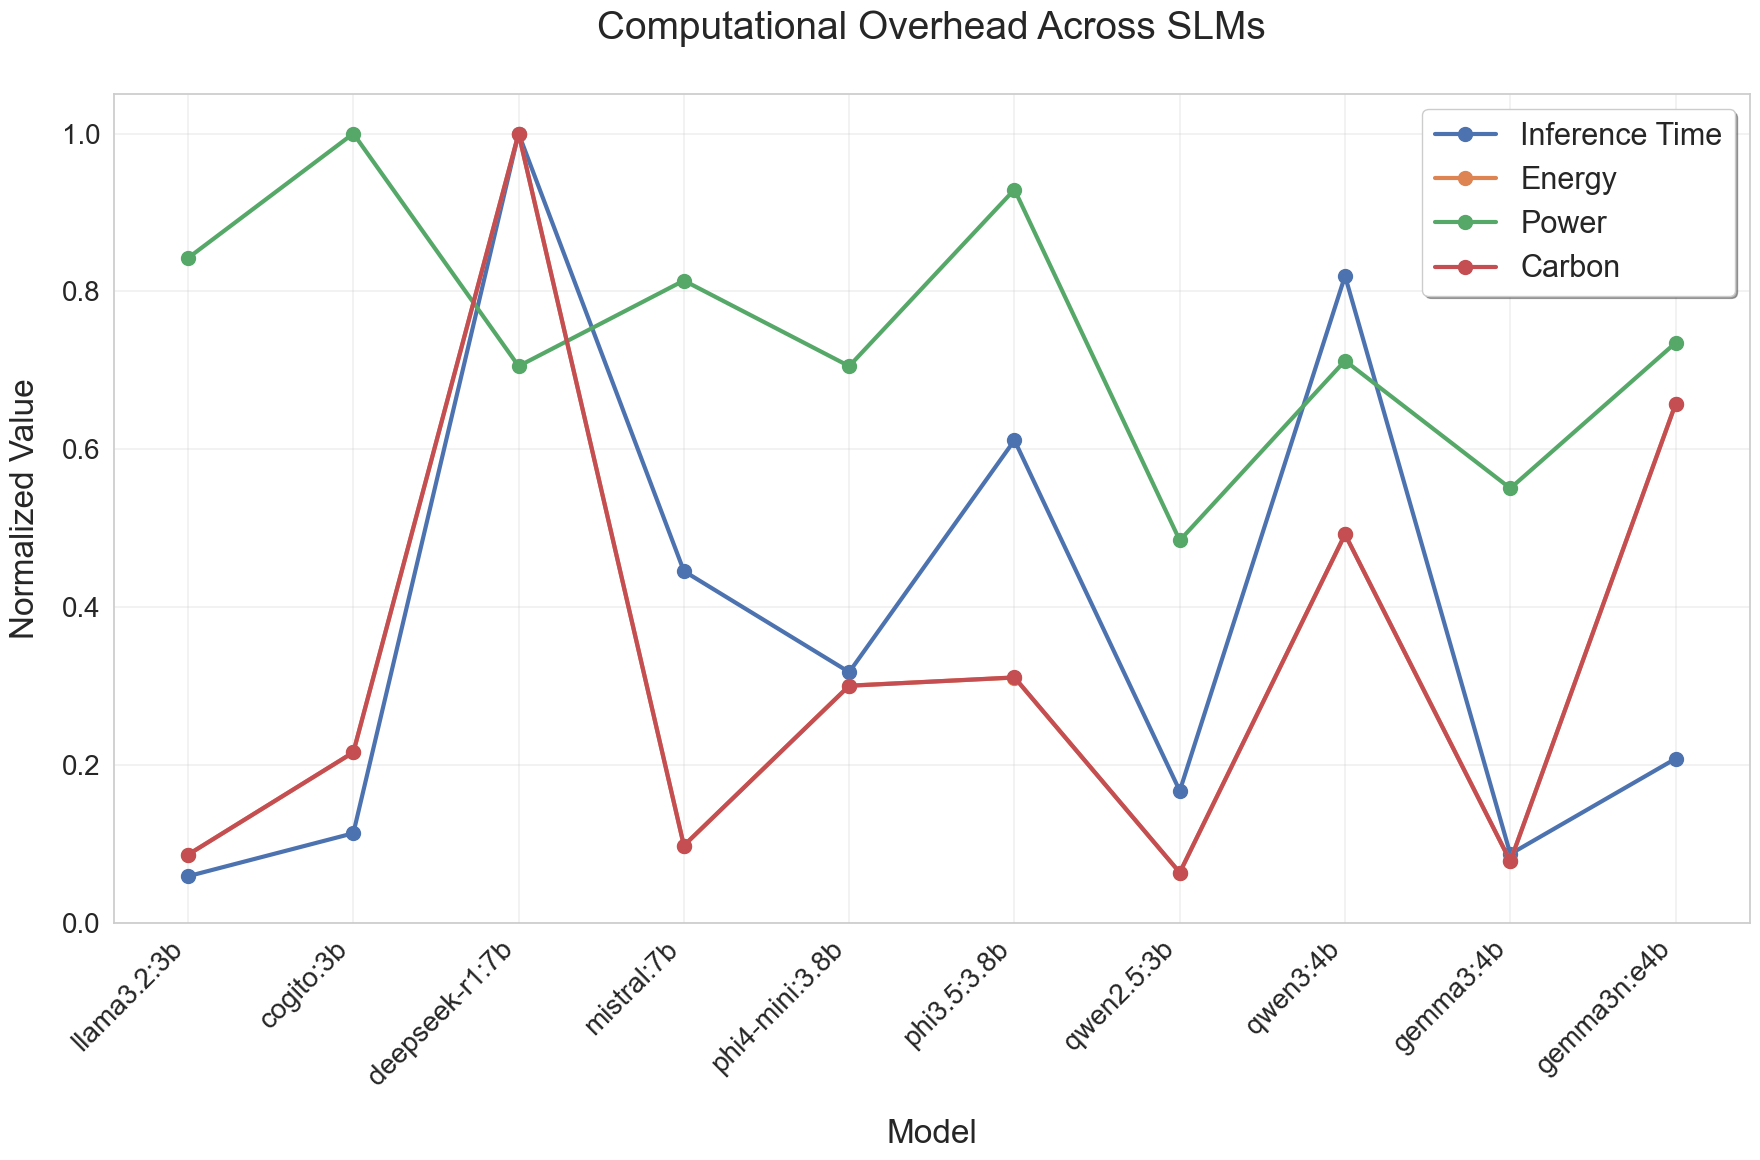

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the data from the table
models = ['llama3.2:3b', 'cogito:3b', 'deepseek-r1:7b', 'mistral:7b', 
         'phi4-mini:3.8b', 'phi3.5:3.8b', 'qwen2.5:3b', 'qwen3:4b', 
         'gemma3:4b', 'gemma3n:e4b']

data_values = {
    'inference_time': [13.75, 26.34, 231.30, 103.13, 73.54, 141.46, 38.76, 189.60, 20.25, 48.18],
    'energy': [116.41, 290.02, 1341.53, 131.88, 403.54, 417.27, 85.98, 660.58, 105.20, 882.57],
    'power': [8.55, 10.15, 7.16, 8.26, 7.16, 9.43, 4.92, 7.23, 5.59, 7.46],
    'carbon': [12.94, 32.27, 149.12, 14.65, 44.83, 46.41, 9.55, 73.43, 11.68, 98.05]
}

# Create a long-format DataFrame
data = []
for metric_name, values in data_values.items():
    for model, value in zip(models, values):
        data.append({
            'model': model,
            'metric': metric_name.replace('_', ' ').title(),
            'value': value
        })

df = pd.DataFrame(data)
df['model'] = pd.Categorical(df['model'], categories=models, ordered=True)

# Set plotting style
sns.set_theme(style="whitegrid")

# Increased font size configuration
TITLE_SIZE = 28
LABEL_SIZE = 24
TICK_SIZE = 20
LEGEND_SIZE = 22

# Explicitly set font sizes for all text elements
plt.rcParams.update({
    'font.size': 20,           # Default font size for all text
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': LEGEND_SIZE
})

# Create the plot with larger figure size
plt.figure(figsize=(18, 12))

# Plot normalized lines for each metric
for metric in df['metric'].unique():
    metric_data = df[df['metric'] == metric]
    # Normalize by maximum value for each metric
    max_value = metric_data['value'].max()
    normalized_values = metric_data['value'] / max_value
    plt.plot(metric_data['model'], normalized_values, 
             marker='o', linewidth=3, markersize=10, label=metric)

# Customize the plot
plt.title('Computational Overhead Across SLMs', fontsize=TITLE_SIZE, pad=40)
plt.xlabel('Model', fontsize=LABEL_SIZE, labelpad=20)
plt.ylabel('Normalized Value', fontsize=LABEL_SIZE, labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Customize legend with larger size and better positioning
plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

# Add grid for better readability
plt.grid(True, alpha=0.3, linewidth=1.2)

# Set y-axis limits to show all data clearly
plt.ylim(0, 1.05)

plt.tight_layout()

# Save the plot with high resolution
plt.savefig('computational_overhead_across_slms.png', dpi=300, bbox_inches='tight')
plt.show()

## Additional Test

In [ ]:
# import os
# import json
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Define the base path
# base_path = '/Users/admin/LG/TextToSQL/query/output'

# # List of models
# models = [
#     'qwen3:4b',
#     'qwen2.5:3b',
#     'phi4-mini:3.8b',
#     'phi3.5:3.8b',
#     'mistral:7b',
#     'llama3.2:latest',
#     'gemma3:4b',
#     'falcon3:3b',
#     'gemma3n:e4b',
#     'deepseek-r1:7b',
#     'cogito:3b'
# ]

# # List of datasets
# datasets = [
#     'country_income',
#     'finance_economics',
#     'global_development',
#     'happiness_record'
# ]

# # Collect data
# data = []

# for model in models:
#     for ds in datasets:
#         # Metrics file path
#         metrics_path = os.path.join(base_path, model, ds, 'comparison', 'metrics.json')
        
#         if os.path.exists(metrics_path):
#             with open(metrics_path, 'r') as f:
#                 metrics = json.load(f)
        
#         # Gold SQL directory
#         gold_dir = os.path.join(base_path, model, ds, 'gold_sql')
        
#         if os.path.exists(gold_dir):
#             for file_name in os.listdir(gold_dir):
#                 if file_name.startswith('question_') and file_name.endswith('.json'):
#                     file_path = os.path.join(gold_dir, file_name)
#                     with open(file_path, 'r') as f:
#                         question_data = json.load(f)
                    
#                     question = question_data.get('question', '')
#                     # Approximate token count as word count
#                     token_count = len(question.split())
                    
#                     # Extract question_id, e.g., 'question_1'
#                     q_id = file_name.split('.')[0]
                    
#                     q_metrics = metrics.get(q_id, {})
                    
#                     # Calculate mean of all metrics for this question
#                     metric_values = [
#                         q_metrics.get('fuzzy_string_similarity', 0),
#                         q_metrics.get('ast_similarity', 0),
#                         q_metrics.get('jaccard_component_similarity', 0),
#                         q_metrics.get('fuzzy_logical_form_similarity', 0),
#                         q_metrics.get('cosine_similarity', 0)
#                     ]
#                     avg_metric = sum(metric_values) / len(metric_values) if metric_values else 0
                    
#                     data.append({
#                         'model': model,
#                         'dataset': ds,
#                         'question_id': q_id,
#                         'token_count': token_count,
#                         'avg_metric': avg_metric
#                     })

# # Create a DataFrame
# df = pd.DataFrame(data)

# # Aggregate data by model, dataset, and token count (average across questions with same token count)
# agg_df = df.groupby(['model', 'dataset', 'token_count'])['avg_metric'].mean().reset_index()

# # Plot one figure per model with 2x2 subplots for each dataset
# unique_models = agg_df['model'].unique()

# for model in unique_models:
#     # Create a 2x2 subplot grid
#     fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
#     axes = axes.flatten()  # Flatten to easily iterate over
    
#     # Plot one subplot per dataset for this model
#     for idx, dataset in enumerate(datasets):
#         dataset_df = agg_df[(agg_df['model'] == model) & (agg_df['dataset'] == dataset)]
#         sns.lineplot(
#             data=dataset_df,
#             x='token_count',
#             y='avg_metric',
#             color='blue',  # Single color since only one line per subplot
#             marker='o',
#             ax=axes[idx]
#         )
#         axes[idx].set_title(f'{dataset.capitalize()}')
#         axes[idx].set_xlabel('Approximate Token Count (Words)')
#         axes[idx].set_ylabel('Average Metric Value')
    
#     # Set main title for the figure
#     fig.suptitle(f'{model} - Average Metric Value vs Approximate Token Count', fontsize=14)
    
#     # Adjust layout to prevent overlap
#     plt.tight_layout()
#     plt.subplots_adjust(top=0.9)  # Adjust top margin for main title
#     plt.show()